<a href="https://colab.research.google.com/github/ranjani-cse/zero-simulation/blob/main/zero_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Setup
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("ZeRO SIMULATION: 32 Virtual GPUs")
print("=" * 60)

NUM_VIRTUAL_GPUS = 32
BYTES_PER_PARAM_FP32 = 4  # 4 bytes for FP32

print(f"Number of virtual GPUs: {NUM_VIRTUAL_GPUS}")
print(f"Bytes per parameter (FP32): {BYTES_PER_PARAM_FP32}")

ZeRO SIMULATION: 32 Virtual GPUs
Number of virtual GPUs: 32
Bytes per parameter (FP32): 4


In [2]:
# Cell 2: Define a demo model
class DemoModel(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=1024, output_dim=512):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = DemoModel()
total_params = sum(p.numel() for p in model.parameters())

print(f"Total parameters: {total_params:,}")
print(f"Model size (FP32): {total_params * 4 / 1e6:.2f} MB")
print(f"\nPer-layer breakdown:")
for name, param in model.named_parameters():
    print(f"  {name}: {param.numel():,} params")

Total parameters: 2,099,712
Model size (FP32): 8.40 MB

Per-layer breakdown:
  fc1.weight: 524,288 params
  fc1.bias: 1,024 params
  fc2.weight: 1,048,576 params
  fc2.bias: 1,024 params
  fc3.weight: 524,288 params
  fc3.bias: 512 params


In [3]:
# Cell 3: Baseline memory (standard DDP — every GPU stores everything)
def calculate_memory_no_zero(num_params, num_gpus, bytes_per_param=4):
    params_mem = num_params * bytes_per_param
    grads_mem = num_params * bytes_per_param
    optimizer_mem = num_params * bytes_per_param * 2  # Adam m + v
    total_per_gpu = params_mem + grads_mem + optimizer_mem
    return {
        "params_per_gpu": params_mem,
        "grads_per_gpu": grads_mem,
        "optimizer_per_gpu": optimizer_mem,
        "total_per_gpu": total_per_gpu,
        "total_cluster": total_per_gpu * num_gpus
    }

baseline = calculate_memory_no_zero(total_params, NUM_VIRTUAL_GPUS)

print("=" * 60)
print("BASELINE (No ZeRO) — Standard DDP")
print("=" * 60)
print(f"Params per GPU:    {baseline['params_per_gpu'] / 1e6:.2f} MB")
print(f"Grads per GPU:     {baseline['grads_per_gpu'] / 1e6:.2f} MB")
print(f"Optimizer per GPU: {baseline['optimizer_per_gpu'] / 1e6:.2f} MB")
print(f"Total per GPU:     {baseline['total_per_gpu'] / 1e6:.2f} MB")
print(f"Total cluster:     {baseline['total_cluster'] / 1e6:.2f} MB")

BASELINE (No ZeRO) — Standard DDP
Params per GPU:    8.40 MB
Grads per GPU:     8.40 MB
Optimizer per GPU: 16.80 MB
Total per GPU:     33.60 MB
Total cluster:     1075.05 MB


In [4]:
# Cell 4: ZeRO-1 — optimizer states partitioned
def calculate_memory_zero1(num_params, num_gpus, bytes_per_param=4):
    params_mem = num_params * bytes_per_param
    grads_mem = num_params * bytes_per_param
    optimizer_mem = (num_params * bytes_per_param * 2) / num_gpus
    total_per_gpu = params_mem + grads_mem + optimizer_mem
    return {
        "params_per_gpu": params_mem,
        "grads_per_gpu": grads_mem,
        "optimizer_per_gpu": optimizer_mem,
        "total_per_gpu": total_per_gpu
    }

zero1 = calculate_memory_zero1(total_params, NUM_VIRTUAL_GPUS)

print("=" * 60)
print("ZeRO-1 — Optimizer states partitioned")
print("=" * 60)
print(f"Params per GPU:    {zero1['params_per_gpu'] / 1e6:.2f} MB  (full copy)")
print(f"Grads per GPU:     {zero1['grads_per_gpu'] / 1e6:.2f} MB  (full copy)")
print(f"Optimizer per GPU: {zero1['optimizer_per_gpu'] / 1e6:.4f} MB  (÷{NUM_VIRTUAL_GPUS})")
print(f"Total per GPU:     {zero1['total_per_gpu'] / 1e6:.2f} MB")

ZeRO-1 — Optimizer states partitioned
Params per GPU:    8.40 MB  (full copy)
Grads per GPU:     8.40 MB  (full copy)
Optimizer per GPU: 0.5249 MB  (÷32)
Total per GPU:     17.32 MB


In [5]:
# Cell 5: ZeRO-2 — optimizer + gradients partitioned
def calculate_memory_zero2(num_params, num_gpus, bytes_per_param=4):
    params_mem = num_params * bytes_per_param
    grads_mem = (num_params * bytes_per_param) / num_gpus
    optimizer_mem = (num_params * bytes_per_param * 2) / num_gpus
    total_per_gpu = params_mem + grads_mem + optimizer_mem
    return {
        "params_per_gpu": params_mem,
        "grads_per_gpu": grads_mem,
        "optimizer_per_gpu": optimizer_mem,
        "total_per_gpu": total_per_gpu
    }

zero2 = calculate_memory_zero2(total_params, NUM_VIRTUAL_GPUS)

print("=" * 60)
print("ZeRO-2 — Optimizer + Gradients partitioned")
print("=" * 60)
print(f"Params per GPU:    {zero2['params_per_gpu'] / 1e6:.2f} MB  (full copy)")
print(f"Grads per GPU:     {zero2['grads_per_gpu'] / 1e6:.4f} MB  (÷{NUM_VIRTUAL_GPUS})")
print(f"Optimizer per GPU: {zero2['optimizer_per_gpu'] / 1e6:.4f} MB  (÷{NUM_VIRTUAL_GPUS})")
print(f"Total per GPU:     {zero2['total_per_gpu'] / 1e6:.2f} MB")

ZeRO-2 — Optimizer + Gradients partitioned
Params per GPU:    8.40 MB  (full copy)
Grads per GPU:     0.2625 MB  (÷32)
Optimizer per GPU: 0.5249 MB  (÷32)
Total per GPU:     9.19 MB


In [6]:
# Cell 6: ZeRO-3 — everything partitioned
def calculate_memory_zero3(num_params, num_gpus, bytes_per_param=4):
    params_mem = (num_params * bytes_per_param) / num_gpus
    grads_mem = (num_params * bytes_per_param) / num_gpus
    optimizer_mem = (num_params * bytes_per_param * 2) / num_gpus
    total_per_gpu = params_mem + grads_mem + optimizer_mem
    return {
        "params_per_gpu": params_mem,
        "grads_per_gpu": grads_mem,
        "optimizer_per_gpu": optimizer_mem,
        "total_per_gpu": total_per_gpu
    }

zero3 = calculate_memory_zero3(total_params, NUM_VIRTUAL_GPUS)

print("=" * 60)
print("ZeRO-3 — Parameters + Gradients + Optimizer states partitioned")
print("=" * 60)
print(f"Params per GPU:    {zero3['params_per_gpu'] / 1e6:.4f} MB  (÷{NUM_VIRTUAL_GPUS})")
print(f"Grads per GPU:     {zero3['grads_per_gpu'] / 1e6:.4f} MB  (÷{NUM_VIRTUAL_GPUS})")
print(f"Optimizer per GPU: {zero3['optimizer_per_gpu'] / 1e6:.4f} MB  (÷{NUM_VIRTUAL_GPUS})")
print(f"Total per GPU:     {zero3['total_per_gpu'] / 1e6:.4f} MB")

ZeRO-3 — Parameters + Gradients + Optimizer states partitioned
Params per GPU:    0.2625 MB  (÷32)
Grads per GPU:     0.2625 MB  (÷32)
Optimizer per GPU: 0.5249 MB  (÷32)
Total per GPU:     1.0499 MB


In [7]:
# Cell 7: Comparison table
print("\n" + "=" * 70)
print("MEMORY COMPARISON (per GPU)")
print("=" * 70)

stages = ["Baseline", "ZeRO-1", "ZeRO-2", "ZeRO-3"]
totals = [
    baseline["total_per_gpu"] / 1e6,
    zero1["total_per_gpu"] / 1e6,
    zero2["total_per_gpu"] / 1e6,
    zero3["total_per_gpu"] / 1e6
]

print(f"{'Stage':<10} {'Total (MB)':<15} {'Reduction':<15}")
print("-" * 45)
for stage, total in zip(stages, totals):
    reduction = (1 - total / totals[0]) * 100
    print(f"{stage:<10} {total:<15.4f} {reduction:<15.2f}%")

# Also show cluster totals
print("\n" + "=" * 70)
print("CLUSTER-WIDE MEMORY (32 GPUs)")
print("=" * 70)
for stage, total in zip(stages, totals):
    cluster = total * NUM_VIRTUAL_GPUS
    print(f"{stage:<10} {cluster:.2f} MB")


MEMORY COMPARISON (per GPU)
Stage      Total (MB)      Reduction      
---------------------------------------------
Baseline   33.5954         0.00           %
ZeRO-1     17.3226         48.44          %
ZeRO-2     9.1862          72.66          %
ZeRO-3     1.0499          96.88          %

CLUSTER-WIDE MEMORY (32 GPUs)
Baseline   1075.05 MB
ZeRO-1     554.32 MB
ZeRO-2     293.96 MB
ZeRO-3     33.60 MB


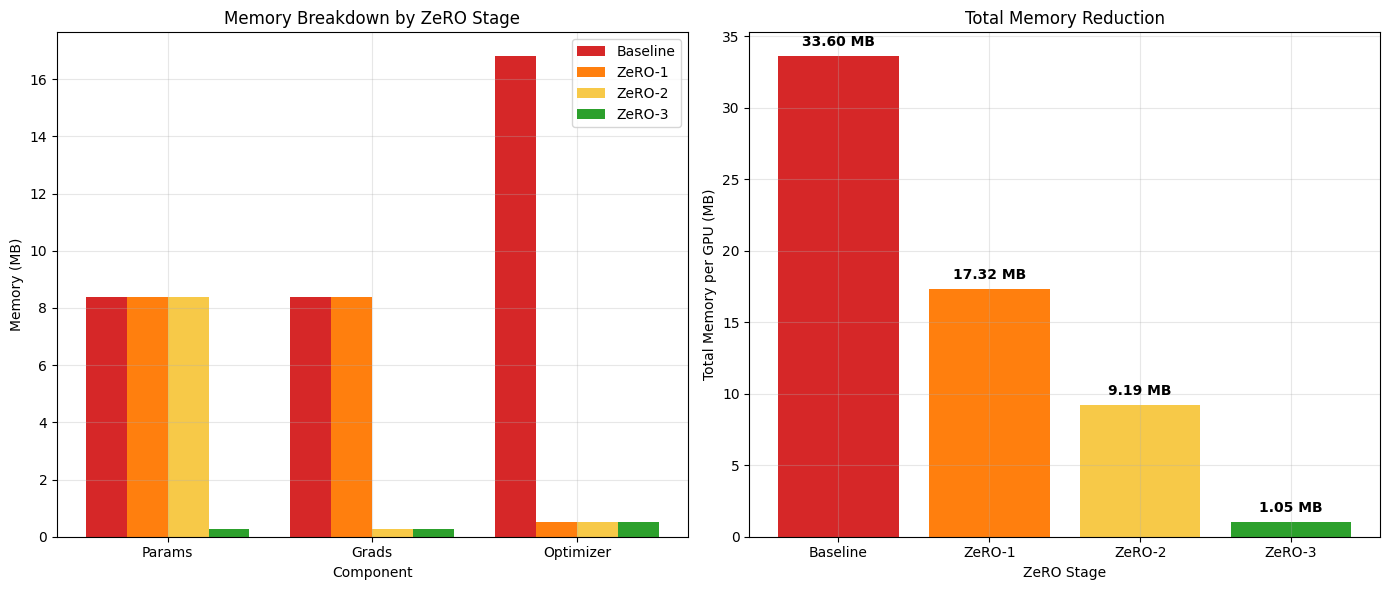


✅ Plot saved: zero_comparison.png


In [8]:
# Cell 8: Visualize memory comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Memory breakdown by component
categories = ["Params", "Grads", "Optimizer"]
baseline_vals = [baseline["params_per_gpu"]/1e6, baseline["grads_per_gpu"]/1e6, baseline["optimizer_per_gpu"]/1e6]
zero1_vals = [zero1["params_per_gpu"]/1e6, zero1["grads_per_gpu"]/1e6, zero1["optimizer_per_gpu"]/1e6]
zero2_vals = [zero2["params_per_gpu"]/1e6, zero2["grads_per_gpu"]/1e6, zero2["optimizer_per_gpu"]/1e6]
zero3_vals = [zero3["params_per_gpu"]/1e6, zero3["grads_per_gpu"]/1e6, zero3["optimizer_per_gpu"]/1e6]

x = np.arange(len(categories))
width = 0.2

axes[0].bar(x - 1.5*width, baseline_vals, width, label='Baseline', color='#d62728')
axes[0].bar(x - 0.5*width, zero1_vals, width, label='ZeRO-1', color='#ff7f0e')
axes[0].bar(x + 0.5*width, zero2_vals, width, label='ZeRO-2', color='#f7c948')
axes[0].bar(x + 1.5*width, zero3_vals, width, label='ZeRO-3', color='#2ca02c')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Memory (MB)')
axes[0].set_title('Memory Breakdown by ZeRO Stage')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Total memory per GPU by stage
stages = ["Baseline", "ZeRO-1", "ZeRO-2", "ZeRO-3"]
totals = [
    baseline["total_per_gpu"] / 1e6,
    zero1["total_per_gpu"] / 1e6,
    zero2["total_per_gpu"] / 1e6,
    zero3["total_per_gpu"] / 1e6
]
colors = ['#d62728', '#ff7f0e', '#f7c948', '#2ca02c']

bars = axes[1].bar(stages, totals, color=colors)
axes[1].set_xlabel('ZeRO Stage')
axes[1].set_ylabel('Total Memory per GPU (MB)')
axes[1].set_title('Total Memory Reduction')
axes[1].grid(True, alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, totals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.2f} MB', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('zero_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Plot saved: zero_comparison.png")

COMMUNICATION OVERHEAD (per training step)

Stage      Memory (MB)     Communication (MB)  
--------------------------------------------------
Baseline   33.60           16.80               
ZeRO-1     17.32           25.20               
ZeRO-2     9.19            16.80               
ZeRO-3     1.05            25.20               


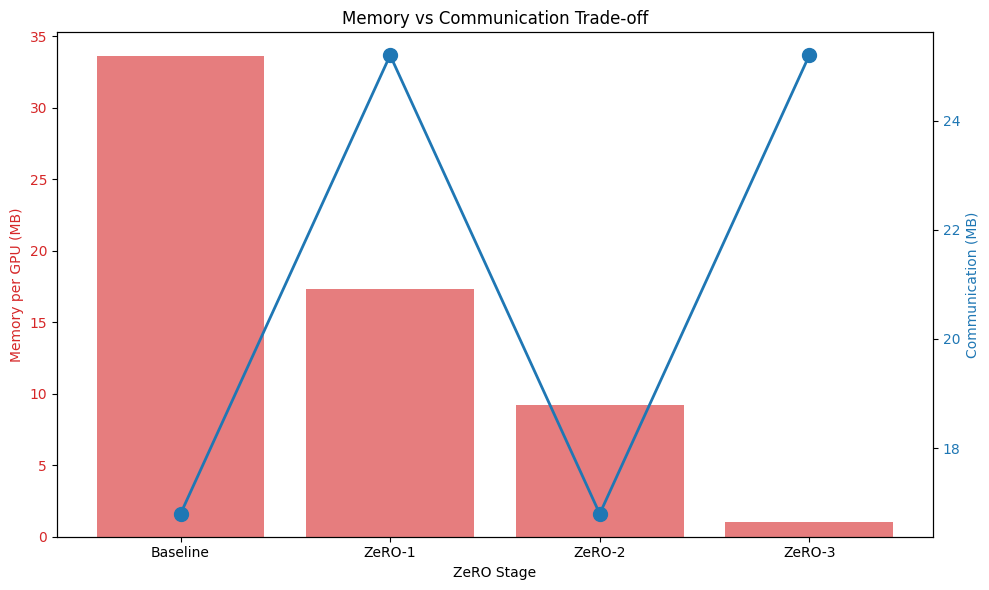


✅ Plot saved: memory_vs_communication.png


In [9]:
# Cell 9: Communication overhead analysis
print("=" * 70)
print("COMMUNICATION OVERHEAD (per training step)")
print("=" * 70)

def communication_cost(stage, num_params, num_gpus, bytes_per_param=4):
    """Estimate communication volume per step (in bytes)."""
    if stage == "Baseline":
        return num_params * bytes_per_param * 2  # all-reduce grads
    elif stage == "ZeRO-1":
        return num_params * bytes_per_param * 3  # all-reduce + broadcast
    elif stage == "ZeRO-2":
        return num_params * bytes_per_param * 2  # reduce-scatter + all-gather
    elif stage == "ZeRO-3":
        return num_params * bytes_per_param * 3  # all-gather params twice + reduce-scatter grads
    return 0

stages = ["Baseline", "ZeRO-1", "ZeRO-2", "ZeRO-3"]
memory_totals = [
    baseline["total_per_gpu"] / 1e6,
    zero1["total_per_gpu"] / 1e6,
    zero2["total_per_gpu"] / 1e6,
    zero3["total_per_gpu"] / 1e6
]
comm_costs = [communication_cost(s, total_params, NUM_VIRTUAL_GPUS) / 1e6 for s in stages]

print(f"\n{'Stage':<10} {'Memory (MB)':<15} {'Communication (MB)':<20}")
print("-" * 50)
for stage, mem, comm in zip(stages, memory_totals, comm_costs):
    print(f"{stage:<10} {mem:<15.2f} {comm:<20.2f}")

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:red'
ax1.set_xlabel('ZeRO Stage')
ax1.set_ylabel('Memory per GPU (MB)', color=color1)
ax1.bar(stages, memory_totals, color=color1, alpha=0.6, label='Memory')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Communication (MB)', color=color2)
ax2.plot(stages, comm_costs, color=color2, marker='o', linewidth=2, markersize=10, label='Communication')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Memory vs Communication Trade-off')
fig.tight_layout()
plt.savefig('memory_vs_communication.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Plot saved: memory_vs_communication.png")